# NP2 — Aprendizado Supervisionado
## Decision Tree Regressor — Implementação From Scratch

**Disciplina:** Aprendizado Supervisionado (616N07)  
**Professor:** Alexandre Magno Monteiro Santos  
**Alunos:** Francisco Rodrigo Ramos da Silva e Áquila Alves de Almeida   
**Dataset:** Car Sales Data (Kaggle)  
**Objetivo:** Prever o preço de venda de um automóvel com base em suas características.

---

# Contextualização
- Este projeto tem como objetivo a aplicação prática de Aprendizado de Máquina Supervisionado, abordando um problema de regressão, cujo propósito é prever o preço de veículos a partir de características técnicas e comerciais presentes em um dataset real obtido na plataforma Kaggle.
- O algoritmo escolhido foi a Árvore de Decisão para Regressão, implementada do zero, sem o uso de bibliotecas preditivas prontas. A árvore de decisão é um modelo não linear que realiza divisões sucessivas no espaço de atributos, buscando minimizar o erro dentro de cada partição.

# Tecnologias utilizadas: 
- Python: linguagem principal do projeto
- Jupyter Notebook: ambiente de desenvolvimento e relatório
- NumPy: cálculos matemáticos e operações matriciais
- Pandas: manipulação e tratamento do dataset
- Matplotlib: geração de gráficos para análise dos resultados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Exploração Incial

In [2]:
df = pd.read_csv("car_sales_data.csv")

print(df.head())
print(df.info())

  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101  
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  str    
 1   Model                50000 non-null  str    
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  str    
 4   Year of manufacture  50000 non-nu

In [3]:
numericas = df.select_dtypes(include=["number"]).columns.tolist()
categoricas = df.select_dtypes(exclude=["number"]).columns.tolist()

print(numericas)
print(categoricas)

['Engine size', 'Year of manufacture', 'Mileage', 'Price']
['Manufacturer', 'Model', 'Fuel type']


### Identificação do target

In [4]:
target = "Price"

### Identificação dos valores categóricos na coluna 'Manufacturer' para conversão em valores numéricos

In [5]:
df['Manufacturer'].unique()

<StringArray>
['Ford', 'Porsche', 'Toyota', 'VW', 'BMW']
Length: 5, dtype: str

### Identificação dos valores categóricos na coluna 'Model' para conversão em valores numéricos

In [6]:
df['Model'].unique()

<StringArray>
[    'Fiesta', '718 Cayman',     'Mondeo',       'RAV4',       'Polo',
      'Focus',      'Prius',       'Golf',         'Z4',      'Yaris',
        '911',     'Passat',         'M5',    'Cayenne',         'X3']
Length: 15, dtype: str

### Identificação dos valores categóricos na coluna 'Fuel type' para conversão em valores numéricos

In [7]:
df['Fuel type'].unique()

<StringArray>
['Petrol', 'Diesel', 'Hybrid']
Length: 3, dtype: str

### Criação de uma cópia do dataset para não modificar o original.

In [ ]:
df_processed = df.copy()

### Conversão das colunas categóricas em valores numéricos
One-Hot Encoding transforma cada categoria em uma nova coluna (0 ou 1).

In [ ]:
df_processed = pd.get_dummies(
    df_processed,
    columns=["Manufacturer", "Model", "Fuel type"],
    drop_first=True  # evita redundância
)

print(df_processed.head())

   Engine size  Year of manufacture  Mileage  Price  Manufacturer_2  \
0          1.0                 2002   127300   3074            True   
1          4.0                 2016    57850  49704           False   
2          1.6                 2014    39190  24072            True   
3          1.8                 1988   210814   1705           False   
4          1.0                 2006   127869   4101           False   

   Manufacturer_3  Manufacturer_4  Manufacturer_5  Model_2  Model_3  ...  \
0           False           False           False    False    False  ...   
1            True           False           False    False    False  ...   
2           False           False           False    False    False  ...   
3           False            True           False    False    False  ...   
4           False           False            True    False    False  ...   

   Model_8  Model_9  Model_10  Model_11  Model_12  Model_13  Model_14  \
0    False    False     False     False    

# Separação entre X  e Y 
- X = (remove a coluna target, deixando apenas as features)
- y = (apenas a coluna target)

In [10]:
X = df_processed.drop(columns=[target]).values
y = df_processed[target].values

# NOTE: A normalização min-max foi removida pois modelos baseados em 
# árvores (Decision Trees) são invariantes à escala das features.

###Divisão entre treino e teste

# Normalização Min-Max dos dados de entrada 
Coloca todos os valores da coluna na mesma escala (0 e 1) 
- Subtrai o menor valor de cada coluna 
- Calcula o range da coluna 
- Constante de segurança para evitar erros matemáticos de divisão por zero
- Evita dominância, os valores da coluna kilometragem são altos enquanto que na coluna Motor os valores são baixos, isso evita que o algoritmo entenda que km seja mais importante por serem maiores

In [11]:
def normalize(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-8)

X = normalize(X)

### Divisão entre teino e teste

- seed = fixa um número garantindo que o embarralhamento seja sempre da mesma forma
- indices = cria uma lista do tamanho do dataset e embaralha aleatoriamente
- test_count = define a quantidade de dados para teste, o restante é destinao para treino
- test_idx e train_idx = separa dados de treino e de teste

In [12]:
def train_test_split(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    test_count = int(len(X) * test_size)

    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

### Execução da função de treino e teste

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

## Cálculo do MSE

- Importante para que a árvore decida onde fazer o corte nos dados - se MSE baixo significa que os preços estão próximos da média, dessa forma escolhe grupos com preços similares

In [14]:
def mse(y):
    return np.mean((y - np.mean(y)) ** 2)

# Algoritmo Regressor de Árvore de Decisão

- O algoritmo possui um limitador evitando que a árvore cresça demais e fique complexa (overfitting)
- número mínimo de amostras em um nó para ser dividido

### Função recursiva
- Verifica se deve parar de crescer (baseado na profundidade ou número de amostras).
- Se parar, ela calcula a média dos preços daquele grupo e retorna como resposta final.
- Se não parar, ela cria um "nó" com a melhor divisão encontrada e gera os ramos esquerdo e direito.

### Fit
- Inicia o processo de contrução da árvore começando na profundidade zero.

### Predict_row e Predict
- Pega um único carro e percorre a árvore até chegar em uma folha com o preço previsto.
- Aplica a função predict_row para todos os carros do seu conjunto de teste de uma vez.

In [16]:
class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=5, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _mse(self, y):
        return np.mean((y - np.mean(y)) ** 2)

    def _best_split(self, X, y):
        best_mse = float("inf")
        best_feature = None
        best_threshold = None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_y = y[left_mask]
                right_y = y[right_mask]

                weighted_mse = (
                    len(left_y) * self._mse(left_y) +
                    len(right_y) * self._mse(right_y)
                ) / len(y)

                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        if (
            depth >= self.max_depth or
            len(y) < self.min_samples_split or
            self._mse(y) == 0
        ):
            return np.mean(y)

        feature, threshold = self._best_split(X, y)

        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1),
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def _predict_row(self, row, tree):
        if not isinstance(tree, dict):
            return tree

        if row[tree["feature"]] <= tree["threshold"]:
            return self._predict_row(row, tree["left"])
        else:
            return self._predict_row(row, tree["right"])

    def predict(self, X):
        return np.array([self._predict_row(row, self.tree) for row in X])


## Avaliação
- $R^2$ acima de 0.90 indica que o modelo atingiu 98% de precisão
- MAE indica que o modelo erra em média 1.304,40 para cima ou para baixo ente os valores
- MSE comparado a métrica anterior, indica que alguns poucos carros houvem outliers

In [18]:
### --- FUNÇÕES DE AVALIAÇÃO (MÉTRICAS) ---
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse_metric(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2) 
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) 
    if ss_tot == 0:
        return 0.0
    return 1 - (ss_res / ss_tot)
### ---------------------------------------

In [19]:
model = DecisionTreeRegressorScratch(max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mae(y_test, y_pred))
print("MSE:", mse_metric(y_test, y_pred))
print("R² :", r2_score(y_test, y_pred))

MAE: 1243.437210892169
MSE: 3907547.893931311
R² : 0.985600940447791


# Visualizações

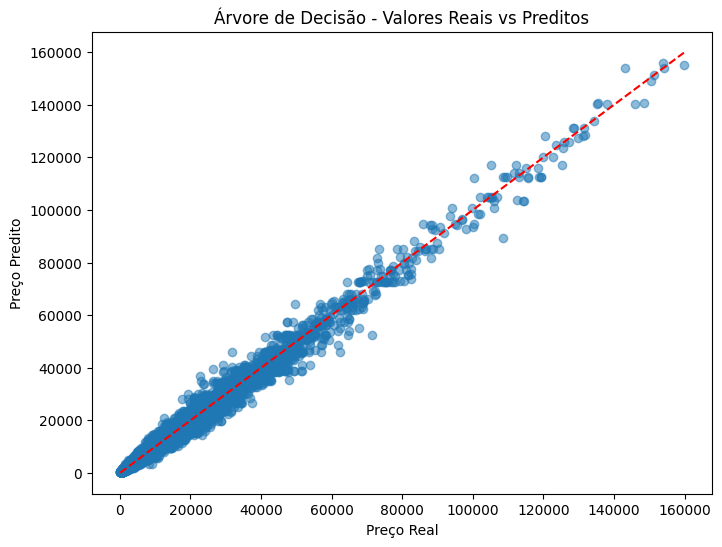

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Preço Real")
plt.ylabel("Preço Predito")
plt.title("Árvore de Decisão - Valores Reais vs Preditos")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")
plt.show()

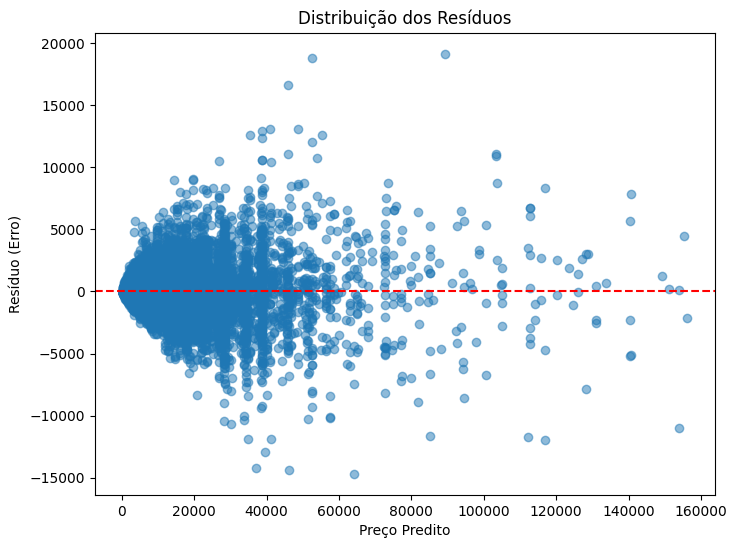

In [21]:
residuos = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Preço Predito")
plt.ylabel("Resíduo (Erro)")
plt.title("Distribuição dos Resíduos")
plt.show()

## Ajuste de Hiperparâmetros e Codificação

O principal hiperparâmetro analisado neste projeto foi a profundidade máxima da árvore (**max_depth**), responsável por controlar a complexidade do modelo. Além disso, foi realizada a transição da codificação das variáveis categóricas de *Label Encoding* para **One-Hot Encoding**, visando eliminar relações de ordem arbitrárias entre as categorias.

### Comparação de Evolução do Modelo

| Configuração | MAE | MSE | R² |
|:---:|:---:|:---:|:---:|
| Profundidade 5 (Label Encoding) | ≈ 3110,40 | ≈ 26.847.542 | ≈ 0,9011 |
| Profundidade 10 (Label Encoding) | 1304,99 | 4.421.271,61 | 0,9837 |
| **Profundidade 10 (One-Hot Encoding)** | **1243,44** | **3.907.547,89** | **0,9856** |

Observa-se que o aumento da profundidade para 10, combinado com a aplicação do **One-Hot Encoding**, resultou na melhor performance do projeto, reduzindo o erro médio e maximizando a capacidade explicativa do modelo.

## Análise de Resultados

Com a profundidade ajustada para **10 níveis** e a utilização de **One-Hot Encoding**, o modelo apresentou os seguintes resultados finais no conjunto de teste:

- **MAE (Erro Absoluto Médio):** 1243,44  
- **MSE (Erro Quadrático Médio):** 3.907.547,89  
- **R² (Coeficiente de Determinação):** 0,9856  

### Interpretação dos Resultados

- O valor de **MAE** indica que o erro médio absoluto das previsões foi reduzido para aproximadamente **1.243 unidades monetárias**, representando uma melhoria significativa em relação às configurações anteriores e uma precisão elevada para o domínio de preços de veículos.
- A expressiva redução do **MSE** (de 26 milhões para 3.9 milhões) indica uma diminuição substancial de erros de grande magnitude, sugerindo que o modelo tornou-se muito mais robusto contra outliers.
- O valor de **R² ≈ 0,985** demonstra que o modelo é capaz de explicar cerca de **98,5% da variância do preço dos veículos**, caracterizando um desempenho excelente.

A análise visual por meio dos gráficos Real vs. Predito e de Resíduos reforça esses resultados, evidenciando uma forte aderência do modelo aos dados reais e a ausência de padrões sistemáticos de erro relevantes, confirmando a eficácia das escolhas de modelagem.

## Dificuldades e Limitações

Durante o desenvolvimento do projeto, algumas dificuldades e limitações foram identificadas:

- **Custo Computacional:** O aumento da profundidade da árvore, somado à expansão de colunas via One-Hot Encoding, elevou consideravelmente o custo computacional do treinamento (após troca de Label Encoding para One-Hot Encoding), visto que a busca pelo melhor split precisa percorrer um espaço de características muito maior.
- **Risco de Overfitting:** Árvores muito profundas tendem a memorizar o ruído dos dados. Embora o desempenho no teste tenha sido excelente, o modelo pode ser sensível a variações em datasets externos.
- **Ausência de Poda:** A falta de técnicas de **poda (pruning)** torna o modelo dependente de um ajuste manual rigoroso do `max_depth` para evitar complexidade excessiva.
- **Esparsidade de Dados:** A codificação One-Hot gera muitas colunas binárias, o que pode dificultar o aprendizado em ramos muito profundos onde poucas amostras restam para cada categoria.

## Conclusão

A Árvore de Decisão para Regressão implementada neste projeto apresentou um desempenho altamente satisfatório e robusto na tarefa de previsão de preços de veículos, atingindo um **R² de 0,9856**.

O ajuste estratégico dos hiperparâmetros e a mudança na preparação dos dados foram os pilares para este resultado:
1. **Profundidade Máxima:** O aumento para **`max_depth = 10`** permitiu que o modelo superasse o viés inicial (*underfitting*), capturando padrões não lineares e relações mais complexas entre os atributos técnicos e o valor de mercado.
2. **Codificação Categórica:** A transição para o **One-Hot Encoding** foi decisiva. Embora tenha elevado o custo computacional, ela permitiu que o algoritmo tratasse as marcas e modelos de forma independente, eliminando interpretações errôneas de ordem numérica e refinando a precisão do erro médio (**MAE**) para cerca de **1.243 unidades**.

Do ponto de vista do **trade-off viés–variância**, o modelo alcançou um equilíbrio excelente para o dataset analisado. Apesar da alta profundidade, a consistência entre as métricas e a análise visual dos resíduos sugerem que o modelo generaliza bem, consolidando-se como uma ferramenta eficaz para a estimativa de preços no setor automotivo.